In [1]:
from src.auth import AuthenticationService
from src.ndvi import extract_ndvi
from src.canopy_height import extract_canopy_height
from src.elevation import extract_elevation
from src.landcover import extract_landcover
from src.worldclim import extract_worldclim
from src.biomass import extract_biomass
from src.waterdist import extract_distance_to_water
from src.nighttime_lights import extract_nighttime_lights
from src.aoi import create_aoi_from_coordinates
from src.utils import plot_map, plot_images
from src.sampling import clean_coordinates_dataframe, convert_points_to_buffered_features
from src.export import export_rasters_to_gdrive, export_csv
import pandas as pd
import ee

In [2]:
GEE_PROJECT_ID = "wildmon-projects"
# LOCATIONS_CSV_PATH = "./input/configuration.csv"
LOCATIONS_CSV_PATH ='/Users/nnbuainain/Downloads/configuration (1).csv'
OUTPUT_CSV_PATH = "output/env_vars.csv"
LAT_COLUMN_NAME = "latitude"
LON_COLUMN_NAME = "longitude"
SAMPLING_POINT_BUFFER_METERS = 200
AOI_BUFFER_KM = 30

In [3]:
ok = AuthenticationService.authenticate(project_id=GEE_PROJECT_ID)
if not ok:
    raise SystemExit("Could not initialize EE")

✅ Google Earth Engine initialized


In [4]:
df = pd.read_csv(LOCATIONS_CSV_PATH)

df = clean_coordinates_dataframe(df,
                                 lat_col=LAT_COLUMN_NAME,
                                 lon_col=LON_COLUMN_NAME)

points_fc = convert_points_to_buffered_features(df,
                                                lat_col=LAT_COLUMN_NAME,
                                                lon_col=LON_COLUMN_NAME,
                                                buffer_meters=SAMPLING_POINT_BUFFER_METERS)

2025-12-01 10:20:44,839 - INFO - Successfully validated and cleaned 78 points.
2025-12-01 10:20:44,840 - INFO - Preparing sampling units for batch processing...


2025-12-01 10:20:44,846 - INFO - Creating map plot for 78 features...
2025-12-01 10:20:49,414 - INFO - Added basemap: satellite
2025-12-01 10:20:49,432 - INFO - Map plot created successfully


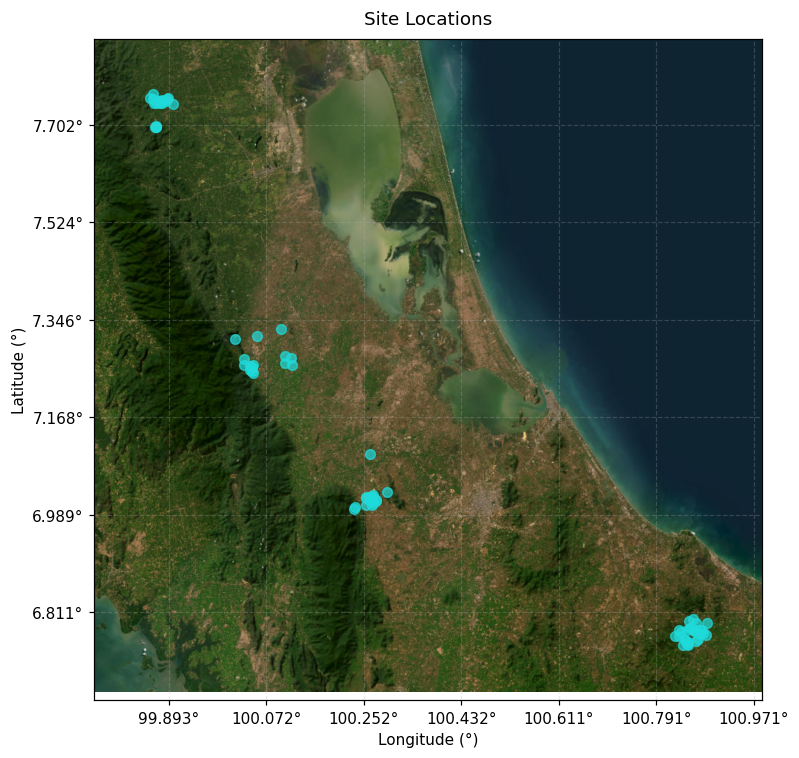

In [5]:
fig, ax = plot_map(df, 
                   basemap='satellite', 
                   alpha=0.7, 
                   color="#1FDBDB", 
                   buffer_pct=0.1,
                   title="Site Locations")  

In [6]:
aoi = create_aoi_from_coordinates(df,
                                  buffer_km=AOI_BUFFER_KM)

📍 AOI Bounds: Lat[6.4810, 8.0283], Lon[99.5855, 101.1565]
📊 Defined study area for 78 points with 30km margin.


In [7]:
# Process NDVI
df, image_ndvi = extract_ndvi(
    df=df,
    aoi=aoi,
    points_feature_collection=points_fc,
    start_date="2021-11-01",
    end_date="2024-12-31",
    scale=30,
    mask_water=True,
    cloud_cover_threshold=20
)
df

2025-12-01 10:20:49,873 - INFO - Processing 78 points...
2025-12-01 10:20:49,874 - INFO - Date range: 2021-11-01 to 2024-12-31
2025-12-01 10:20:49,874 - INFO - Scale: 30m
2025-12-01 10:20:49,875 - INFO - Water masking: True
2025-12-01 10:20:49,875 - INFO - Creating Landsat composite for study area...
2025-12-01 10:20:50,173 - INFO - Found 74 Landsat 9 images for study area
2025-12-01 10:20:50,174 - INFO - Loading GLCF water mask...
2025-12-01 10:20:50,175 - INFO - Extracting NDVI statistics for each sampling unit...
2025-12-01 10:20:50,178 - INFO - Fetching results from Earth Engine...
2025-12-01 10:20:50,697 - INFO - Parsing results...
2025-12-01 10:20:50,698 - INFO - Successfully processed 78/78 points
2025-12-01 10:20:50,699 - INFO - NDVI range: 0.612 to 0.866
2025-12-01 10:20:50,699 - INFO - NDVI mean: 0.802 ± 0.049


,site_name,latitude,longitude,filename_format,filename_offset_hours,unnamed: 5,tags,NDVI_mean,NDVI_std
0,T1_W_03000,7.749,99.890,SM-ABC123DEF_YYYYMMDD_HHmmss,6,NaN,Wanakset,0.817,0.037
1,T1_M_02887,7.317,100.055,SM-ABC123DEF_YYYYMMDD_HHmmss,6,NaN,Monoculture,0.836,0.027
2,T1_W_02571,7.275,100.031,SM-ABC123DEF_YYYYMMDD_HHmmss,6,NaN,Wanakset,0.780,0.092
3,T1_F_02908,7.263,100.031,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Forest,0.864,0.012
4,T1_W_02745,7.248,100.047,SM-ABC123DEF_YYYYMMDD_HHmmss,6,NaN,Wanakset,0.846,0.016
...,...,...,...,...,...,...,...,...,...
73,NMR_T2_F_02909,7.254,100.042,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Forest,0.803,0.075
74,NMR_T2_W_02571,7.267,100.107,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Wanakset,0.758,0.087
75,NMR_T2_M_03000,7.277,100.118,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Monoculture,0.709,0.137
76,NMR_T2_W_02934,7.264,100.119,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Wanakset,0.768,0.076


In [10]:
df, image_elevation = extract_elevation(df=df,
                                        aoi=aoi,
                                        points_feature_collection=points_fc,
                                        scale=30)
df

2025-12-01 10:21:08,667 - INFO - Processing 78 points...
2025-12-01 10:21:08,668 - INFO - Scale: 30m
2025-12-01 10:21:08,668 - INFO - Loading SRTM elevation dataset...
2025-12-01 10:21:08,669 - INFO - Extracting elevation and slope statistics...
2025-12-01 10:21:08,673 - INFO - Fetching results from Earth Engine...
2025-12-01 10:21:09,027 - INFO - Merging elevation and slope values into dataframe...
2025-12-01 10:21:09,028 - INFO - Successfully processed 78/78 points with elevation data
2025-12-01 10:21:09,029 - INFO - Successfully processed 78/78 points with slope data
2025-12-01 10:21:09,029 - INFO - Elevation mean: 74.87 ± 32.85 m (range 32.49-217.36 m)
2025-12-01 10:21:09,029 - INFO - Slope mean: 14.30 ± 8.16 deg (range 5.28-44.73 deg)


,site_name,latitude,longitude,filename_format,filename_offset_hours,unnamed: 5,tags,NDVI_mean,NDVI_std,elevation_mean,elevation_std,slope_percent_mean,slope_percent_std
0,T1_W_03000,7.749,99.890,SM-ABC123DEF_YYYYMMDD_HHmmss,6,NaN,Wanakset,0.817,0.037,54.066,4.155,8.772,5.060
1,T1_M_02887,7.317,100.055,SM-ABC123DEF_YYYYMMDD_HHmmss,6,NaN,Monoculture,0.836,0.027,63.971,8.412,12.802,6.986
2,T1_W_02571,7.275,100.031,SM-ABC123DEF_YYYYMMDD_HHmmss,6,NaN,Wanakset,0.780,0.092,63.853,3.260,6.488,3.916
3,T1_F_02908,7.263,100.031,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Forest,0.864,0.012,117.889,23.944,25.393,14.624
4,T1_W_02745,7.248,100.047,SM-ABC123DEF_YYYYMMDD_HHmmss,6,NaN,Wanakset,0.846,0.016,101.717,13.642,19.529,12.377
...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,NMR_T2_F_02909,7.254,100.042,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Forest,0.803,0.075,88.695,10.032,12.747,9.653
74,NMR_T2_W_02571,7.267,100.107,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Wanakset,0.758,0.087,47.450,4.210,8.081,5.072
75,NMR_T2_M_03000,7.277,100.118,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Monoculture,0.709,0.137,38.832,2.943,6.197,3.870
76,NMR_T2_W_02934,7.264,100.119,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Wanakset,0.768,0.076,46.980,3.293,6.835,4.257


In [11]:
df, image_canopy_height = extract_canopy_height(df,
                                                aoi=aoi,
                                                points_feature_collection=points_fc,
                                                scale=10)
df

2025-12-01 10:21:09,051 - INFO - Processing 78 points...
2025-12-01 10:21:09,051 - INFO - Scale: 10m
2025-12-01 10:21:09,052 - INFO - Loading ETH Global Canopy Height dataset...
2025-12-01 10:21:09,052 - INFO - Extracting canopy height statistics...
2025-12-01 10:21:09,054 - INFO - Fetching results from Earth Engine...
2025-12-01 10:21:09,802 - INFO - Merging canopy height values into dataframe...
2025-12-01 10:21:09,803 - INFO - Successfully processed 78/78 points with canopy data
2025-12-01 10:21:09,804 - INFO - Canopy height mean: 15.94 ± 3.99 m (range 9.67-30.23 m)


,site_name,latitude,longitude,filename_format,filename_offset_hours,unnamed: 5,tags,NDVI_mean,NDVI_std,elevation_mean,elevation_std,slope_percent_mean,slope_percent_std,canopy_height_mean,canopy_height_std
0,T1_W_03000,7.749,99.890,SM-ABC123DEF_YYYYMMDD_HHmmss,6,NaN,Wanakset,0.817,0.037,54.066,4.155,8.772,5.060,13.936,2.229
1,T1_M_02887,7.317,100.055,SM-ABC123DEF_YYYYMMDD_HHmmss,6,NaN,Monoculture,0.836,0.027,63.971,8.412,12.802,6.986,15.240,3.090
2,T1_W_02571,7.275,100.031,SM-ABC123DEF_YYYYMMDD_HHmmss,6,NaN,Wanakset,0.780,0.092,63.853,3.260,6.488,3.916,17.660,3.078
3,T1_F_02908,7.263,100.031,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Forest,0.864,0.012,117.889,23.944,25.393,14.624,30.233,2.389
4,T1_W_02745,7.248,100.047,SM-ABC123DEF_YYYYMMDD_HHmmss,6,NaN,Wanakset,0.846,0.016,101.717,13.642,19.529,12.377,22.247,2.884
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,NMR_T2_F_02909,7.254,100.042,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Forest,0.803,0.075,88.695,10.032,12.747,9.653,29.473,6.175
74,NMR_T2_W_02571,7.267,100.107,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Wanakset,0.758,0.087,47.450,4.210,8.081,5.072,14.366,2.209
75,NMR_T2_M_03000,7.277,100.118,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Monoculture,0.709,0.137,38.832,2.943,6.197,3.870,14.075,2.717
76,NMR_T2_W_02934,7.264,100.119,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Wanakset,0.768,0.076,46.980,3.293,6.835,4.257,13.526,2.135


In [12]:
df, image_worldclim = extract_worldclim(df,
                                        aoi=aoi,
                                        points_feature_collection=points_fc,
                                        # variables=['bio01', 'bio02'], # uncomment to select specific variables
                                        )
df

2025-12-01 10:21:20,788 - INFO - Processing 78 points...
2025-12-01 10:21:20,788 - INFO - Variables: bio01, bio02, bio03, bio04, bio05, bio06, bio07, bio08, bio09, bio10, bio11, bio12, bio13, bio14, bio15, bio16, bio17, bio18, bio19
2025-12-01 10:21:20,789 - INFO - Scale: 1000m
2025-12-01 10:21:20,789 - INFO - Loading WorldClim image for study area...
2025-12-01 10:21:20,790 - INFO - Extracting bioclimatic statistics...
2025-12-01 10:21:20,794 - INFO - Fetching results from Earth Engine...
2025-12-01 10:21:21,884 - INFO - Merging WorldClim results into dataframe...
2025-12-01 10:21:21,892 - INFO - Successfully processed 78/78 points with WorldClim data
2025-12-01 10:21:21,893 - INFO - Annual Mean Temperature (bio01): 26.5°C to 27.4°C (mean 27.1°C)
2025-12-01 10:21:21,893 - INFO - Annual Precipitation (bio12): 1718mm to 2037mm (mean 1886mm)


,site_name,latitude,longitude,filename_format,filename_offset_hours,unnamed: 5,tags,NDVI_mean,NDVI_std,elevation_mean,...,bio15_mean,bio15_stdDev,bio16_mean,bio16_stdDev,bio17_mean,bio17_stdDev,bio18_mean,bio18_stdDev,bio19_mean,bio19_stdDev
0,T1_W_03000,7.749,99.890,SM-ABC123DEF_YYYYMMDD_HHmmss,6,NaN,Wanakset,0.817,0.037,54.066,...,61.000,0.000,991.000,0.00,191.000,0.0,289.000,0.000,783.000,0.000
1,T1_M_02887,7.317,100.055,SM-ABC123DEF_YYYYMMDD_HHmmss,6,NaN,Monoculture,0.836,0.027,63.971,...,58.000,0.000,930.000,0.00,178.000,0.0,315.000,0.000,716.000,0.000
2,T1_W_02571,7.275,100.031,SM-ABC123DEF_YYYYMMDD_HHmmss,6,NaN,Wanakset,0.780,0.092,63.853,...,55.781,0.433,901.500,3.24,173.500,1.0,330.656,2.165,682.500,3.961
3,T1_F_02908,7.263,100.031,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Forest,0.864,0.012,117.889,...,55.000,0.000,894.161,3.00,173.613,1.0,341.258,4.500,672.742,4.500
4,T1_W_02745,7.248,100.047,SM-ABC123DEF_YYYYMMDD_HHmmss,6,NaN,Wanakset,0.846,0.016,101.717,...,55.750,0.500,898.000,2.00,171.250,0.5,334.500,3.000,679.750,2.500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,NMR_T2_F_02909,7.254,100.042,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Forest,0.803,0.075,88.695,...,55.903,0.500,898.613,2.00,170.903,0.5,333.194,1.000,680.419,3.000
74,NMR_T2_W_02571,7.267,100.107,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Wanakset,0.758,0.087,47.450,...,60.000,0.000,938.000,0.00,174.000,0.0,313.000,0.000,729.000,0.000
75,NMR_T2_M_03000,7.277,100.118,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Monoculture,0.709,0.137,38.832,...,61.000,0.000,950.000,0.00,175.000,0.0,375.000,0.000,744.000,0.000
76,NMR_T2_W_02934,7.264,100.119,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Wanakset,0.768,0.076,46.980,...,60.094,0.500,941.375,2.00,172.187,1.0,317.281,33.500,734.469,2.500


In [14]:
df, image_landcover = extract_landcover(
    df,
    aoi=aoi,
    points_feature_collection=points_fc,
    scale=10
)
df

2025-12-01 10:21:50,253 - INFO - Processing 78 points...
2025-12-01 10:21:50,253 - INFO - Date range: 2021
2025-12-01 10:21:50,253 - INFO - Scale: 10m
2025-12-01 10:21:50,254 - INFO - Loading ESA WorldCover composite for study area...
2025-12-01 10:21:50,254 - INFO - Extracting dominant landcover and class proportions...
2025-12-01 10:21:50,259 - INFO - Fetching landcover statistics from Earth Engine...
2025-12-01 10:21:50,963 - INFO - Merging landcover results into dataframe...
2025-12-01 10:21:50,966 - INFO - Successfully processed 78/78 points with landcover data
2025-12-01 10:21:50,967 - INFO - Dominant landcover distribution:
2025-12-01 10:21:50,967 - INFO -   Tree_cover: 78 points (100.0%)


,site_name,latitude,longitude,filename_format,filename_offset_hours,unnamed: 5,tags,NDVI_mean,NDVI_std,elevation_mean,...,landcover_prop_Grassland,landcover_prop_Cropland,landcover_prop_Built_up,landcover_prop_Bare_sparse_vegetation,landcover_prop_Snow_and_ice,landcover_prop_Permanent_water_bodies,landcover_prop_Herbaceous_wetland,landcover_prop_Mangroves,landcover_prop_Moss_and_lichen,landcover_dominant_label
0,T1_W_03000,7.749,99.890,SM-ABC123DEF_YYYYMMDD_HHmmss,6,NaN,Wanakset,0.817,0.037,54.066,...,0.087,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,Tree_cover
1,T1_M_02887,7.317,100.055,SM-ABC123DEF_YYYYMMDD_HHmmss,6,NaN,Monoculture,0.836,0.027,63.971,...,0.000,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,Tree_cover
2,T1_W_02571,7.275,100.031,SM-ABC123DEF_YYYYMMDD_HHmmss,6,NaN,Wanakset,0.780,0.092,63.853,...,0.070,0.003,0.000,0.0,0.0,0.0,0.0,0.0,0.0,Tree_cover
3,T1_F_02908,7.263,100.031,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Forest,0.864,0.012,117.889,...,0.000,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,Tree_cover
4,T1_W_02745,7.248,100.047,SM-ABC123DEF_YYYYMMDD_HHmmss,6,NaN,Wanakset,0.846,0.016,101.717,...,0.001,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,Tree_cover
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,NMR_T2_F_02909,7.254,100.042,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Forest,0.803,0.075,88.695,...,0.062,0.006,0.000,0.0,0.0,0.0,0.0,0.0,0.0,Tree_cover
74,NMR_T2_W_02571,7.267,100.107,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Wanakset,0.758,0.087,47.450,...,0.009,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,Tree_cover
75,NMR_T2_M_03000,7.277,100.118,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Monoculture,0.709,0.137,38.832,...,0.122,0.000,0.034,0.0,0.0,0.0,0.0,0.0,0.0,Tree_cover
76,NMR_T2_W_02934,7.264,100.119,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Wanakset,0.768,0.076,46.980,...,0.082,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,Tree_cover


In [19]:
df, image_waterdist = extract_distance_to_water(
    df,
    aoi=aoi,
    points_feature_collection=points_fc,
    scale=30,
    max_search_distance=5_000,
)
df

2025-12-01 10:24:44,580 - INFO - Processing 78 points for distance-to-water calculation...
2025-12-01 10:24:44,580 - INFO - Sampling scale: 30m
2025-12-01 10:24:44,580 - INFO - Max search distance: 5000m
2025-12-01 10:24:44,581 - INFO - Loading water datasets at native resolution...
2025-12-01 10:24:44,581 - INFO - Combining water layers...
2025-12-01 10:24:44,581 - INFO - Building distance surface using FDT...
2025-12-01 10:24:44,582 - INFO - Sampling distance values at sampling point centroids...
2025-12-01 10:24:44,584 - INFO - Fetching distance results...
2025-12-01 10:24:46,189 - INFO - Merging distances into dataframe...
2025-12-01 10:24:46,191 - INFO - Successfully processed 78/78 points with distance-to-water data
2025-12-01 10:24:46,192 - INFO - Distance to water: median 1919.1 m (min 60.0 m, max 5001.0 m)


,site_name,latitude,longitude,filename_format,filename_offset_hours,unnamed: 5,tags,NDVI_mean,NDVI_std,elevation_mean,...,landcover_prop_Cropland,landcover_prop_Built_up,landcover_prop_Bare_sparse_vegetation,landcover_prop_Snow_and_ice,landcover_prop_Permanent_water_bodies,landcover_prop_Herbaceous_wetland,landcover_prop_Mangroves,landcover_prop_Moss_and_lichen,landcover_dominant_label,distance_to_water_m
0,T1_W_03000,7.749,99.890,SM-ABC123DEF_YYYYMMDD_HHmmss,6,NaN,Wanakset,0.817,0.037,54.066,...,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,Tree_cover,2994.295
1,T1_M_02887,7.317,100.055,SM-ABC123DEF_YYYYMMDD_HHmmss,6,NaN,Monoculture,0.836,0.027,63.971,...,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,Tree_cover,5001.000
2,T1_W_02571,7.275,100.031,SM-ABC123DEF_YYYYMMDD_HHmmss,6,NaN,Wanakset,0.780,0.092,63.853,...,0.003,0.000,0.0,0.0,0.0,0.0,0.0,0.0,Tree_cover,5001.000
3,T1_F_02908,7.263,100.031,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Forest,0.864,0.012,117.889,...,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,Tree_cover,5001.000
4,T1_W_02745,7.248,100.047,SM-ABC123DEF_YYYYMMDD_HHmmss,6,NaN,Wanakset,0.846,0.016,101.717,...,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,Tree_cover,5001.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,NMR_T2_F_02909,7.254,100.042,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Forest,0.803,0.075,88.695,...,0.006,0.000,0.0,0.0,0.0,0.0,0.0,0.0,Tree_cover,5001.000
74,NMR_T2_W_02571,7.267,100.107,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Wanakset,0.758,0.087,47.450,...,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,Tree_cover,5001.000
75,NMR_T2_M_03000,7.277,100.118,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Monoculture,0.709,0.137,38.832,...,0.000,0.034,0.0,0.0,0.0,0.0,0.0,0.0,Tree_cover,5001.000
76,NMR_T2_W_02934,7.264,100.119,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Wanakset,0.768,0.076,46.980,...,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,Tree_cover,5001.000


In [25]:
df, image_biomass = extract_biomass(
    df,
    aoi=aoi,
    points_feature_collection=points_fc,
    scale=100,
    year=2022
)
df

2025-12-01 10:58:53,548 - INFO - Processing 78 points for biomass extraction...
2025-12-01 10:58:53,548 - INFO - Requested year: 2022
2025-12-01 10:58:53,549 - INFO - Scale: 100m
2025-12-01 10:58:53,549 - INFO - Loading ESA CCI AGB image...
2025-12-01 10:58:53,771 - INFO - Extracting biomass statistics...
2025-12-01 10:58:53,774 - INFO - Fetching biomass results from Earth Engine...
2025-12-01 10:58:54,220 - INFO - Merging biomass results into dataframe...
2025-12-01 10:58:54,221 - INFO - Successfully processed 78/78 points with biomass data
2025-12-01 10:58:54,221 - INFO - Biomass mean: 105.65 ± 28.85 t/ha (range 53.36-166.28 t/ha)


,site_name,latitude,longitude,filename_format,filename_offset_hours,unnamed: 5,tags,NDVI_mean,NDVI_std,elevation_mean,...,landcover_prop_Bare_sparse_vegetation,landcover_prop_Snow_and_ice,landcover_prop_Permanent_water_bodies,landcover_prop_Herbaceous_wetland,landcover_prop_Mangroves,landcover_prop_Moss_and_lichen,landcover_dominant_label,distance_to_water_m,biomass_mean,biomass_std
0,T1_W_03000,7.749,99.890,SM-ABC123DEF_YYYYMMDD_HHmmss,6,NaN,Wanakset,0.817,0.037,54.066,...,0.0,0.0,0.0,0.0,0.0,0.0,Tree_cover,2994.295,96.547,51.337
1,T1_M_02887,7.317,100.055,SM-ABC123DEF_YYYYMMDD_HHmmss,6,NaN,Monoculture,0.836,0.027,63.971,...,0.0,0.0,0.0,0.0,0.0,0.0,Tree_cover,5001.000,117.297,26.482
2,T1_W_02571,7.275,100.031,SM-ABC123DEF_YYYYMMDD_HHmmss,6,NaN,Wanakset,0.780,0.092,63.853,...,0.0,0.0,0.0,0.0,0.0,0.0,Tree_cover,5001.000,89.405,22.453
3,T1_F_02908,7.263,100.031,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Forest,0.864,0.012,117.889,...,0.0,0.0,0.0,0.0,0.0,0.0,Tree_cover,5001.000,129.875,23.237
4,T1_W_02745,7.248,100.047,SM-ABC123DEF_YYYYMMDD_HHmmss,6,NaN,Wanakset,0.846,0.016,101.717,...,0.0,0.0,0.0,0.0,0.0,0.0,Tree_cover,5001.000,156.964,20.599
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,NMR_T2_F_02909,7.254,100.042,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Forest,0.803,0.075,88.695,...,0.0,0.0,0.0,0.0,0.0,0.0,Tree_cover,5001.000,105.312,29.874
74,NMR_T2_W_02571,7.267,100.107,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Wanakset,0.758,0.087,47.450,...,0.0,0.0,0.0,0.0,0.0,0.0,Tree_cover,5001.000,76.447,37.065
75,NMR_T2_M_03000,7.277,100.118,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Monoculture,0.709,0.137,38.832,...,0.0,0.0,0.0,0.0,0.0,0.0,Tree_cover,5001.000,58.071,21.387
76,NMR_T2_W_02934,7.264,100.119,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Wanakset,0.768,0.076,46.980,...,0.0,0.0,0.0,0.0,0.0,0.0,Tree_cover,5001.000,77.881,39.765


In [26]:
df, image_nightlights = extract_nighttime_lights(
    df,
    aoi=aoi,
    points_feature_collection=points_fc,
    scale=464,
    year=2022
)
df

2025-12-01 10:59:02,679 - INFO - Processing 78 points for nighttime lights extraction...
2025-12-01 10:59:02,679 - INFO - Requested year: 2022
2025-12-01 10:59:02,679 - INFO - Scale: 464m
2025-12-01 10:59:02,680 - INFO - Loading VIIRS annual nighttime lights image...
2025-12-01 10:59:02,884 - INFO - Extracting nighttime lights statistics...
2025-12-01 10:59:02,887 - INFO - Fetching nighttime lights results from Earth Engine...
2025-12-01 10:59:03,626 - INFO - Merging nighttime lights results into dataframe...
2025-12-01 10:59:03,628 - INFO - Successfully processed 78/78 points with nighttime lights data
2025-12-01 10:59:03,628 - INFO - Nighttime lights mean: 0.86 ± 0.73 (range 0.32-3.70)


,site_name,latitude,longitude,filename_format,filename_offset_hours,unnamed: 5,tags,NDVI_mean,NDVI_std,elevation_mean,...,landcover_prop_Permanent_water_bodies,landcover_prop_Herbaceous_wetland,landcover_prop_Mangroves,landcover_prop_Moss_and_lichen,landcover_dominant_label,distance_to_water_m,biomass_mean,biomass_std,nightlights_mean,nightlights_std
0,T1_W_03000,7.749,99.890,SM-ABC123DEF_YYYYMMDD_HHmmss,6,NaN,Wanakset,0.817,0.037,54.066,...,0.0,0.0,0.0,0.0,Tree_cover,2994.295,96.547,51.337,0.670,0.075
1,T1_M_02887,7.317,100.055,SM-ABC123DEF_YYYYMMDD_HHmmss,6,NaN,Monoculture,0.836,0.027,63.971,...,0.0,0.0,0.0,0.0,Tree_cover,5001.000,117.297,26.482,0.504,0.039
2,T1_W_02571,7.275,100.031,SM-ABC123DEF_YYYYMMDD_HHmmss,6,NaN,Wanakset,0.780,0.092,63.853,...,0.0,0.0,0.0,0.0,Tree_cover,5001.000,89.405,22.453,0.400,0.000
3,T1_F_02908,7.263,100.031,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Forest,0.864,0.012,117.889,...,0.0,0.0,0.0,0.0,Tree_cover,5001.000,129.875,23.237,0.324,0.000
4,T1_W_02745,7.248,100.047,SM-ABC123DEF_YYYYMMDD_HHmmss,6,NaN,Wanakset,0.846,0.016,101.717,...,0.0,0.0,0.0,0.0,Tree_cover,5001.000,156.964,20.599,0.386,0.027
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,NMR_T2_F_02909,7.254,100.042,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Forest,0.803,0.075,88.695,...,0.0,0.0,0.0,0.0,Tree_cover,5001.000,105.312,29.874,0.340,0.013
74,NMR_T2_W_02571,7.267,100.107,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Wanakset,0.758,0.087,47.450,...,0.0,0.0,0.0,0.0,Tree_cover,5001.000,76.447,37.065,0.938,0.075
75,NMR_T2_M_03000,7.277,100.118,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Monoculture,0.709,0.137,38.832,...,0.0,0.0,0.0,0.0,Tree_cover,5001.000,58.071,21.387,1.827,0.461
76,NMR_T2_W_02934,7.264,100.119,SM-ABC123DEF_YYYYMMDD_HHmmss,0,NaN,Wanakset,0.768,0.076,46.980,...,0.0,0.0,0.0,0.0,Tree_cover,5001.000,77.881,39.765,0.668,0.031


In [27]:
image_with_indices = ee.Image.cat([
    image_ndvi,
    image_elevation,
    image_canopy_height,
    image_landcover,
    image_waterdist,
    image_biomass,
    image_nightlights,
    image_worldclim
])

In [29]:
map = plot_images(image_waterdist,
                  aoi=aoi,
                  zoom=10,
                  scale=30
                #   filter_bands=['elevation'],
                  )
map

2025-12-01 11:00:32,732 - INFO - Available bands in image: water_mask, distance_to_water_m
2025-12-01 11:00:32,732 - INFO - Plotting 2 bands: water_mask, distance_to_water_m
2025-12-01 11:00:36,742 - INFO - Band 'water_mask': min=1.0000, max=1.0000
2025-12-01 11:00:43,814 - INFO - Band 'distance_to_water_m': min=0.0000, max=5010.0000
2025-12-01 11:00:44,167 - INFO - Map created successfully


Map(center=[7.254440530915388, 100.37100000000002], controls=(WidgetControl(options=['position', 'transparent_…

In [32]:
export_csv(df, OUTPUT_CSV_PATH)


Result saved to output/env_vars.csv


In [30]:
image_with_indices = ee.Image.cat([
    image_waterdist,
])

In [31]:
export_rasters_to_gdrive(
    image=image_with_indices,
    region=aoi,
    file_name_prefix="2025",
    scale=200,
    crs="EPSG:3857",
    file_format="GeoTIFF")

✅ Started export for band: water_mask -> 2025_water_mask
✅ Started export for band: distance_to_water_m -> 2025_distance_to_water_m
🔗 Monitor progress at: https://code.earthengine.google.com/tasks


___